### Use Case: Feature Adversaries Attack on MNIST

__Step 1__: Prepare an MNIST Classifier using pytorch framework.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from art.attacks.evasion import FeatureAdversariesPyTorch
from art.estimators.classification import PyTorchClassifier
from art.utils import load_mnist


# Step 1: Load the MNIST dataset

(x_train, y_train), (x_test, y_test), min_pixel_value, max_pixel_value = load_mnist()

# Step 1a: Swap axes to PyTorch's NCHW format

x_train = np.transpose(x_train, (0, 3, 1, 2)).astype(np.float32)
x_test = np.transpose(x_test, (0, 3, 1, 2)).astype(np.float32)

# Step 2: Create the model

model = nn.Sequential(
    nn.Conv2d(1, 4, 5), nn.ReLU(), nn.MaxPool2d(2, 2), 
    nn.Conv2d(4, 10, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
    nn.Flatten(), 
    nn.Linear(4*4*10, 100),    
    nn.Linear(100, 10)
)
# Step 2a: Define the loss function and the optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Step 3: Create the ART classifier

classifier = PyTorchClassifier(
    model=model,
    clip_values=(min_pixel_value, max_pixel_value),
    loss=criterion,
    optimizer=optimizer,
    input_shape=(1, 28, 28),
    nb_classes=10,
)

# Step 4: Train the ART classifier

classifier.fit(x_train, y_train, batch_size=64, nb_epochs=3)

# Step 5: Evaluate the ART classifier on benign test examples

predictions = classifier.predict(x_test)
accuracy = np.sum(np.argmax(predictions, axis=1) == np.argmax(y_test, axis=1)) / len(y_test)
print("Accuracy on benign test examples: {}%".format(accuracy * 100))

/home/nura-kawa/Projects/localized-classmap/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nura-kawa/Projects/localized-classmap/env/lib/python3.12/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


Accuracy on benign test examples: 97.13000000000001%


In [2]:
# Step 5: prepare a batch of source and guide images
valid = np.argmax(y_test, axis=1)[:100] != np.argmax(y_test, axis=1)[100:200]
source = x_test[:100][valid][:32]
guide = x_test[100:200][valid][:32]

In [3]:
# Step 6: Generate adversarial test examples
attack = FeatureAdversariesPyTorch(
    classifier,
    layer=7,
    delta=35/255, #35/255 in the example, but 10/255 in paper 
    optimizer=None,
    step_size= 1/255,
    max_iter=300,
)
x_adv = attack.generate(source, guide)

# Step 7: Evaluate the ART classifier on adversarial test examples

predictions = classifier.predict(x_adv)
y_adv = y_test[:100][valid][:32]

accuracy = np.sum(np.argmax(predictions, axis=1) == np.argmax(y_adv, axis=1)) / len(y_adv)

dim = tuple(range(1, len(source.shape)))
pert = np.mean(np.amax(np.abs(source - x_adv), axis=dim))
print("Accuracy on adversarial test batch: {}%".format(accuracy * 100))
print("Average perturbation: {}%".format(pert))

Feature Adversaries PyTorch:   0%|          | 0/300 [00:00<?, ?it/s]

Feature Adversaries PyTorch: 100%|██████████| 300/300 [00:02<00:00, 146.07it/s]

Accuracy on adversarial test batch: 6.25%
Average perturbation: 0.13725492358207703%


### Visualize Adversarial Examples

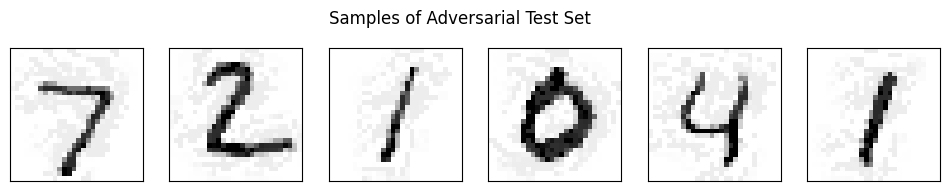

In [4]:
# Number of rows and columns
num_row = 1
num_col = 6

# Create the subplot grid with specified figure size
fig, axes = plt.subplots(num_row, num_col, figsize=(12, 2))

# Plot the images
for i in range(6):
    #ax = axes[i//num_col, i%num_col]
    ax = axes[i]
    img = x_adv[i,...].squeeze()
    ax.imshow(img, cmap='Greys')

    # Remove axis labels, ticks, and numbers
    ax.set_xticks([])
    ax.set_yticks([])
    #ax.set_frame_on(False)  # Remove the axis frame

# Remove whitespace around and within the plots
# plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)

# Add the title
fig.suptitle('Samples of Adversarial Test Set', y=1.02)

# Show the plot
plt.show()


### Explanations + Examples

Searching for 10 nearest neighbors for 10032 points. This could take some time!
Nearest neighbor search complete !


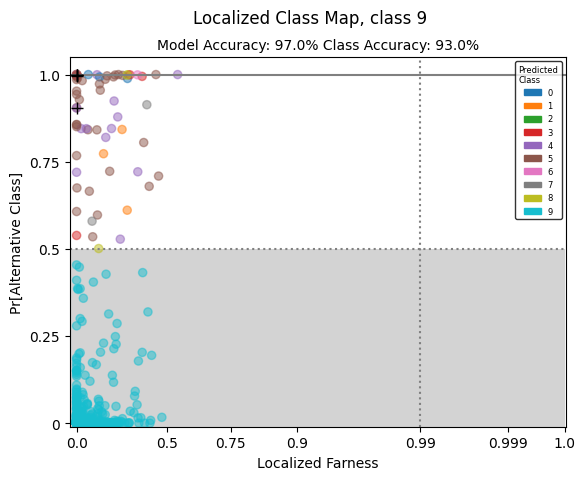

In [5]:
# source localized classmap
exec(open('localized_classmap.py').read())

# Model Explanation

plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=10,
    cl=9,
    annotate=True,

    pytorch=True)

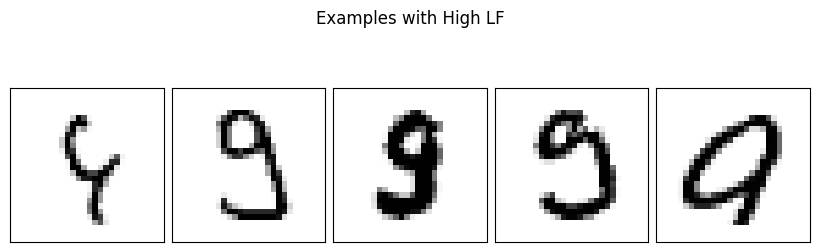

In [6]:
# Examples with high LF

high_LF = [186, 343, 149, 116, 665]

# Number of rows and columns
num_row = 1
num_col = len(high_LF)

# Create the subplot grid with specified figure size
fig, axes = plt.subplots(num_row, num_col, figsize=(8, 3))

# Plot the images
for i in range(num_col):
    ax = axes[i]
    img = x_test[np.argmax(y_test, axis=1)==9][high_LF[i],...].squeeze()
    ax.imshow(img, cmap='Greys')

    # Remove axis labels, ticks, and numbers
    ax.set_xticks([])
    ax.set_yticks([])

# Add the title
fig.suptitle('Examples with High LF', y=1.02)


# Remove whitespace around and within the plots
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)


# Show the plot
plt.show()

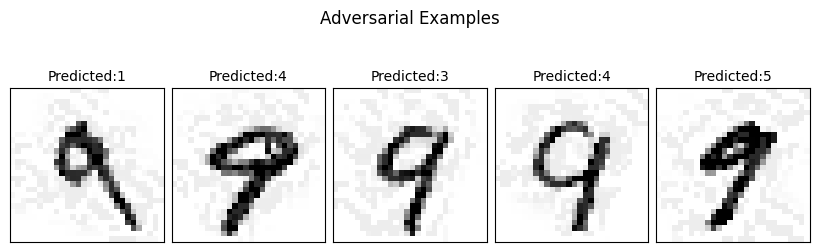

In [7]:
# Adversarial Examples

adv_examples = [7, 9, 12, 16, 20]

# Number of rows and columns
num_row = 1
num_col = len(adv_examples)

# Create the subplot grid with specified figure size
fig, axes = plt.subplots(num_row, num_col, figsize=(8, 3))

# Plot the images
for i in range(num_col):
    ax = axes[i] #axes[0,i]
    img = x_adv[adv_examples[i],...].squeeze()
    ax.imshow(img, cmap='Greys')

    # Remove axis labels, ticks, and numbers
    ax.set_xticks([])
    ax.set_yticks([])

    # Predicted as
    ax.set_title(f'Predicted:{np.argmax(predictions,axis=1)[adv_examples[i]]}', fontsize=10)

# # Plot the images
# for i in range(num_col):
#     ax = axes[1,i]
#     img = guide[adv_examples[i],...].squeeze()
#     ax.imshow(img, cmap='Greys')

    # Remove axis labels, ticks, and numbers
    ax.set_xticks([])
    ax.set_yticks([])

# Remove whitespace around and within the plots
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)

# Add row-wise titles using fig.text() for custom positioning
# fig.text(-0.02, 0.25, 'Adversarial Example', ha='center', fontsize=10, rotation=90)  # Title for the first row
# fig.text(-0.01, 0.01, 'Guide Image', ha='center', fontsize=10, rotation=90)  # Title for the second row

# Add the title
fig.suptitle('Adversarial Examples', y=1.02)

# Show the plot
plt.show()

Searching for 40 nearest neighbors for 10032 points. This could take some time!
Nearest neighbor search complete !


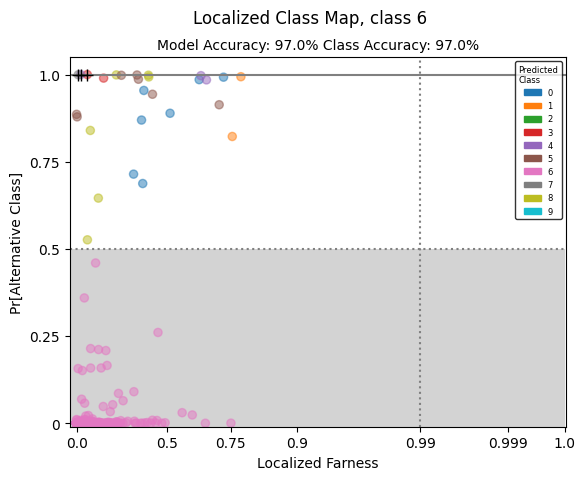

In [8]:
plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=40,
    cl=6,
    annotate=True,
    pytorch=True)

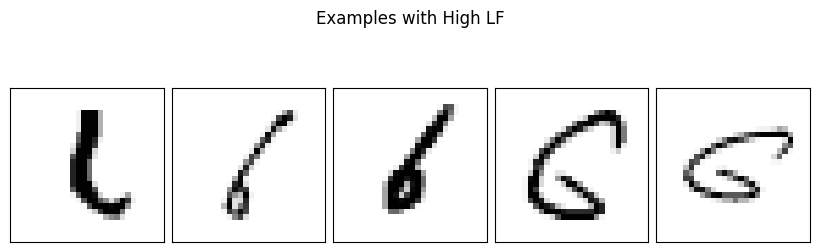

In [9]:
# Examples with high LF

high_LF = [236, 192, 101, 363, 87]

# Number of rows and columns
num_row = 1
num_col = len(high_LF)

# Create the subplot grid with specified figure size
fig, axes = plt.subplots(num_row, num_col, figsize=(8, 3))

# Plot the images
for i in range(num_col):
    ax = axes[i]
    img = x_test[np.argmax(y_test, axis=1)==6][high_LF[i],...].squeeze()
    ax.imshow(img, cmap='Greys')

    # Remove axis labels, ticks, and numbers
    ax.set_xticks([])
    ax.set_yticks([])

# Add the title
fig.suptitle('Examples with High LF', y=1.02)


# Remove whitespace around and within the plots
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.05, hspace=0.05)


# Show the plot
plt.show()

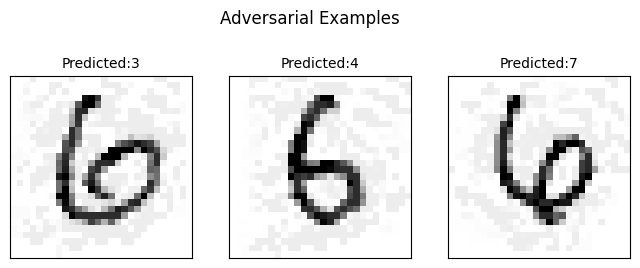

In [10]:
# Adversarial Examples

adv_examples = [11, 21, 22]

# Number of rows and columns
num_row = 1
num_col = len(adv_examples)

# Create the subplot grid with specified figure size
fig, axes = plt.subplots(num_row, num_col, figsize=(8, 3))

# Plot the images
for i in range(num_col):
    ax = axes[i] #axes[0,i]
    img = x_adv[adv_examples[i],...].squeeze()
    ax.imshow(img, cmap='Greys')

    # Remove axis labels, ticks, and numbers
    ax.set_xticks([])
    ax.set_yticks([])

    # Predicted as
    ax.set_title(f'Predicted:{np.argmax(predictions,axis=1)[adv_examples[i]]}', fontsize=10)

    # Remove axis labels, ticks, and numbers
    ax.set_xticks([])
    ax.set_yticks([])


# Add the title
fig.suptitle('Adversarial Examples', y=1.02)

# Show the plot
plt.show()

Searching for 40 nearest neighbors for 10032 points. This could take some time!
Nearest neighbor search complete !


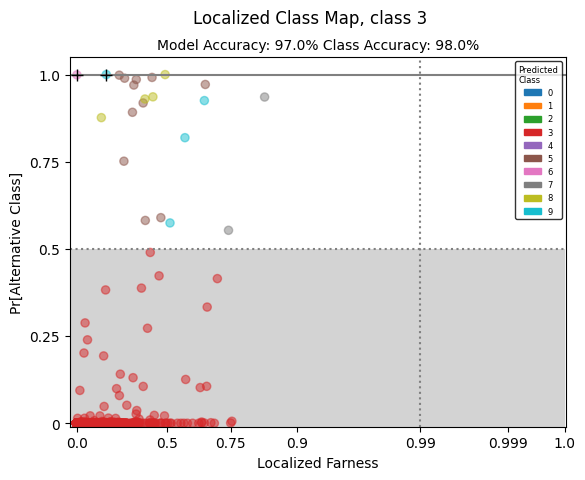

In [11]:
plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=40,
    cl=3,
    annotate=True,
    pytorch=True)

In [12]:
plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=40,
    cl=2,
    annotate=True,
    pytorch=True)

Searching for 40 nearest neighbors for 10032 points. This could take some time!


KeyboardInterrupt: 

Adversarial accuracy: 0.0 %
Searching for 40 nearest neighbors for 10032 points. This could take some time!
Nearest neighbor search complete !
Top 5 Far Examples:
[441 251 348 486 259]
(array([10002, 10005, 10014, 10029, 10031]),)
[10002]


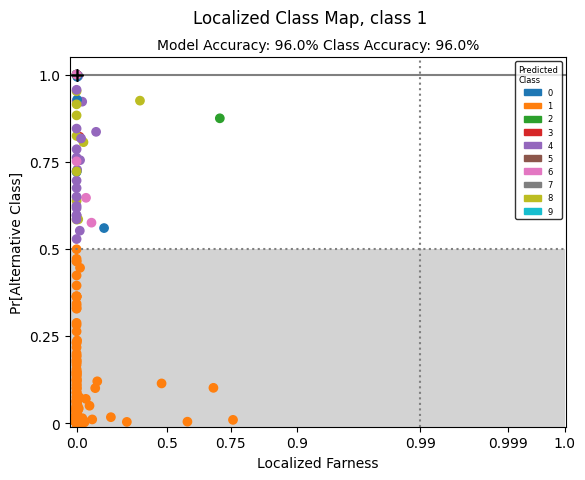

In [97]:
plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=40,
    cl=1,
    annotate=True,
    pytorch=True)

Adversarial accuracy: 0.0 %
Searching for 40 nearest neighbors for 10032 points. This could take some time!
Nearest neighbor search complete !
Top 5 Far Examples:
[398 500 347 150 129]
(array([10000, 10017, 10026]),)
[10000]


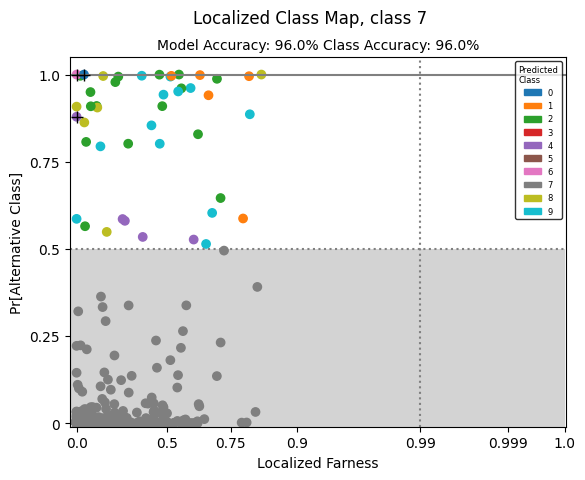

In [99]:
plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=40,
    cl=7,
    annotate=True,
    pytorch=True)

Adversarial accuracy: 0.0 %
Searching for 40 nearest neighbors for 10032 points. This could take some time!
Nearest neighbor search complete !
Top 5 Far Examples:
[629 634 942 966 807]
(array([10003, 10010, 10013, 10025, 10028]),)
[10003]


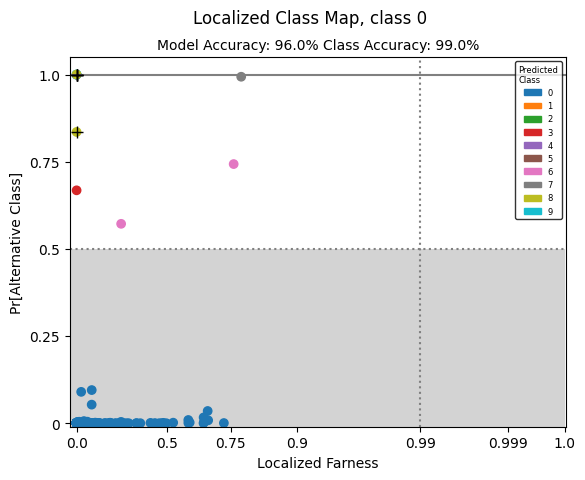

In [100]:
plotExplanationsAdversarial(
    model=classifier,
    X=x_test,
    y=np.argmax(y_test, axis=1),
    X_adv = x_adv,
    y_adv = np.argmax(y_adv, axis=1),
    k=40,
    cl=0,
    annotate=True,
    pytorch=True)